 # Linear Convection Equation (LCE)



 We start with the 1D linear convection equation:



 $$

 \frac{\partial u}{\partial t} + c \frac{\partial u}{\partial x} = 0

 $$



 where:



 - $u(x,t)$ is the transported scalar

 - $c$ is constant wave speed



 This equation models pure advection without diffusion.



 ---



 ## Exact Solution



 For initial condition $u(x,0) = u_0(x)$, the exact solution is:



 $$

 u(x,t) = u_0(x - ct)

 $$



 The solution simply translates with speed $c$.



 ---



 ## Initial Condition



 We use a Gaussian:



 $$

 u(x,0) = \exp(-\alpha (x - x_0)^2)

 $$



 ---



 ## Boundary Condition



 We impose **periodic boundary conditions**:



 $$

 u(0,t) = u(L,t)

 $$



 This allows the wave to wrap around the domain.

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
c = 1.0
L = 1.0
N = 101
dx = L/(N-1)
x = np.linspace(0, L, N)

CFL = 0.5
dt = CFL*dx/c

t_final = 1.0
n_steps = int(t_final/dt)

x0 = 0.25
alpha = 1000

# Initial condition
def initial_condition(x):
    return np.exp(-alpha*(x-x0)**2)

u0 = initial_condition(x)

def exact_solution(x, t):
    x_shift = (x - c*t) % L
    return np.exp(-alpha*(x_shift - x0)**2)



 ## 1) FTBS Scheme (Forward Time, Backward Space)



 The discretization:



 $$

 u_i^{n+1} = u_i^n - \text{CFL} (u_i^n - u_{i-1}^n)

 $$



 where:



 $$

 \text{CFL} = \frac{c \Delta t}{\Delta x}

 $$



 This is an **upwind scheme** for $c > 0$.



 It is:

 - First-order accurate

 - Stable for CFL ≤ 1

 - Numerically diffusive

In [16]:
def ftbs(u0, n_steps):
    u = u0.copy()
    history = [u.copy()]
    
    for n in range(n_steps):
        u_new = u.copy()
        u_new[1:] = u[1:] - CFL*(u[1:] - u[:-1])
        u_new[0]  = u[0] - CFL*(u[0] - u[-1])  # periodic BC
        u = u_new
        history.append(u.copy())
        
    return history

history_ftbs = ftbs(u0, n_steps)


 ## 2) FTCS Scheme (Forward Time, Central Space)



 Discretization:



 $$

 u_i^{n+1} = u_i^n - \frac{\text{CFL}}{2} (u_{i+1}^n - u_{i-1}^n)

 $$



 This scheme is:



 - Second-order in space

 - First-order in time

 - **Unconditionally unstable**



 Even for small CFL, oscillations grow.

In [17]:
def ftcs(u0, n_steps):
    u = u0.copy()
    history = [u.copy()]
    
    for n in range(n_steps):
        u_new = u.copy()
        u_new[1:-1] = u[1:-1] - 0.5*CFL*(u[2:] - u[:-2])
        u_new[0]  = u[0] - 0.5*CFL*(u[1] - u[-1])
        u_new[-1] = u[-1] - 0.5*CFL*(u[0] - u[-2])
        u = u_new
        history.append(u.copy())
        
    return history

history_ftcs = ftcs(u0, n_steps)


 ## 3) FTFS Scheme (Forward Time, Forward Space)



 Discretization:



 $$

 u_i^{n+1} = u_i^n - \text{CFL} (u_{i+1}^n - u_i^n)

 $$



 This is a **downwind scheme** for $c > 0$.



 It is unstable because information propagates opposite

 to the physical wave direction.

In [18]:
def ftfs(u0, n_steps):
    u = u0.copy()
    history = [u.copy()]
    
    for n in range(n_steps):
        u_new = u.copy()
        u_new[:-1] = u[:-1] - CFL*(u[1:] - u[:-1])
        u_new[-1]  = u[-1] - CFL*(u[0] - u[-1])
        u = u_new
        history.append(u.copy())
        
    return history

history_ftfs = ftfs(u0, n_steps)


 # Energy Stability Study



 Define discrete energy:



 $$

 E^n = \sum_i (u_i^n)^2

 $$



 A stable numerical scheme should not cause energy to grow unbounded.



 - FTBS → energy decays (numerical diffusion)

 - FTCS → energy grows

 - FTFS → energy grows rapidly

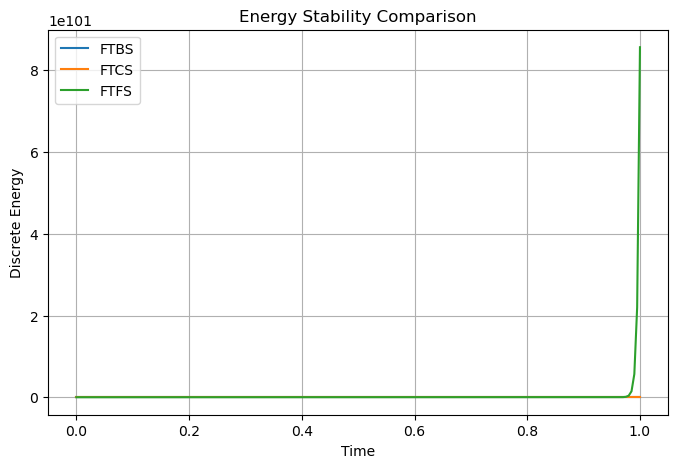

In [19]:
def compute_energy(history):
    return [np.sum(u**2) for u in history]

energy_ftbs = compute_energy(history_ftbs)
energy_ftcs = compute_energy(history_ftcs)
energy_ftfs = compute_energy(history_ftfs)

time = np.arange(n_steps+1)*dt

plt.figure(figsize=(8,5))
plt.plot(time, energy_ftbs, label="FTBS")
plt.plot(time, energy_ftcs, label="FTCS")
plt.plot(time, energy_ftfs, label="FTFS")
plt.xlabel("Time")
plt.ylabel("Discrete Energy")
plt.title("Energy Stability Comparison")
plt.legend()
plt.grid()
plt.show()


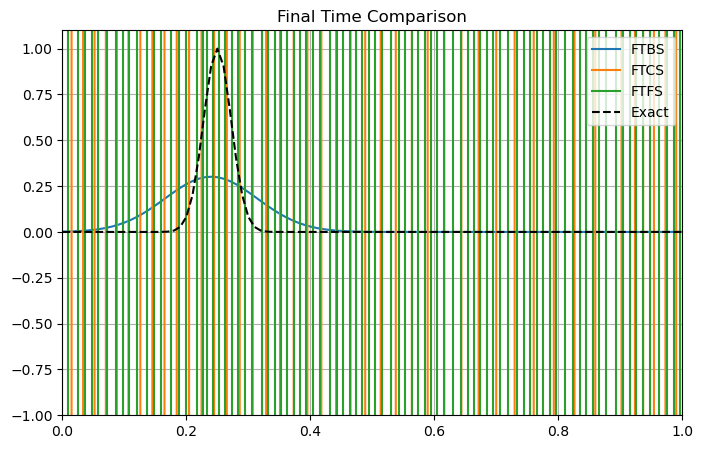

In [20]:
plt.figure(figsize=(8,5))

plt.plot(x, history_ftbs[-1], label="FTBS")
plt.plot(x, history_ftcs[-1], label="FTCS")
plt.plot(x, history_ftfs[-1], label="FTFS")
plt.plot(x, exact_solution(x, t_final), 'k--', label="Exact")

plt.ylim(-1, 1.1)   # Restrict y-axis
plt.xlim(0, L)      # (optional but recommended)

plt.legend()
plt.grid()
plt.title("Final Time Comparison")
plt.show()


 # Embedded Animations



 We now animate:



 - FTBS (stable, diffusive)

 - FTCS (unstable)

 - FTFS (unstable)



 Each animation compares numerical and exact solutions.

In [21]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def animate_scheme(history, scheme_name):
    
    fig, ax = plt.subplots(figsize=(8,5))
    line_num, = ax.plot([], [], label=scheme_name)
    line_exact, = ax.plot([], [], 'k--', label='Exact')
    
    ax.set_xlim(0, L)
    ax.set_ylim(-0.2, 1.2)
    ax.set_xlabel('x')
    ax.set_ylabel('u')
    ax.legend()
    ax.grid()
    
    def update(frame):
        t = frame * dt
        line_num.set_data(x, history[frame])
        line_exact.set_data(x, exact_solution(x, t))
        ax.set_title(f"{scheme_name} | t = {t:.3f}")
        return line_num, line_exact
    
    ani = FuncAnimation(fig, update,
                        frames=n_steps,
                        interval=40,
                        blit=True)
    
    plt.close(fig)
    return HTML(ani.to_html5_video())

 ## FTBS Animation (Stable, Diffusive)

In [22]:
animate_scheme(history_ftbs, "FTBS")

 ## FTCS Animation (Unstable)

In [23]:
animate_scheme(history_ftcs, "FTCS")

In [24]:
# ## FTFS Animation (Unstable)

In [25]:
animate_scheme(history_ftfs, "FTFS")

